In [7]:
%pip install -U langchain-experimental

Note: you may need to restart the kernel to use updated packages.


In [1]:
from typing_extensions import Literal
from langchain_core.tools import tool
from langchain_groq import ChatGroq
from langgraph.graph import MessagesState, StateGraph, START, END
from langgraph.types import Command
from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.prebuilt import create_react_agent
from typing import Annotated
from langchain_experimental.utilities import PythonREPL

C:\Users\LOQ\AppData\Local\Temp\ipykernel_7300\2236239879.py:11: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.utilities import PythonREPL


In [2]:
load_dotenv()

True

In [3]:
groq_model = ChatGroq(model= "llama-3.1-8b-instant")

In [4]:
groq_model.invoke("Hi")

AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.027332039, 'prompt_time': 0.001794683, 'queue_time': 0.048275486, 'total_time': 0.029126722}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e8eaa-f45f-74f2-a017-833643361d19-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59})

In [33]:
def add_numbers(state):
    result = state["num1"] + state["num2"]
    print(f"additional result: {result}")
    return Command(goto = "multiply", update = {"sum":result})

In [34]:
state = {"num1": 1, "num2": 2}

In [35]:
add_numbers(state)

additional result: 3


Command(update={'sum': 3}, goto='multiply')

In [29]:
@tool
def transfer_to_multiplication_expert():
    """Ask multiplication agent for help"""
    return

In [30]:
@tool
def transfer_to_addition_expert():
    """Ask addition agent for help"""
    return

In [36]:
model_with_tool = groq_model.bind_tools([transfer_to_multiplication_expert])

In [37]:
model_with_tool.invoke("Hi how are you?")

AIMessage(content="I'm functioning properly, thank you for asking. I'm a large language model, so I don't have emotions or feelings like humans do, but I'm here to help and provide information to the best of my ability. How can I assist you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 214, 'total_tokens': 267, 'completion_time': 0.482714266, 'prompt_time': 0.019150049, 'queue_time': 0.078599171, 'total_time': 0.501864315}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e8ece-73db-7452-b1c9-adc3b6043926-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 214, 'output_tokens': 53, 'total_tokens': 267})

In [38]:
ai_message = model_with_tool.invoke("Hi how are you?")

In [39]:
ai_message.tool_calls

[]

In [40]:
ai_message = model_with_tool.invoke("what's (3+5) * 12. Provide me the output")

In [41]:
ai_message.tool_calls

[{'name': 'transfer_to_multiplication_expert',
  'args': {},
  'id': '4x2xxn89f',
  'type': 'tool_call'}]

In [31]:
def addition_expert_node(state: MessagesState) -> Command[Literal["addition_expert", "multiplication_expert", "__end__"]]:
    system_prompt = (
        "You are an addition expert, you can ask the multiplication expert for help with multiplication."
        "Always do your portion of calculation before the handoff."
    )

    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    ai_msg = groq_model.bind_tools([transfer_to_multiplication_expert]).invoke(messages)
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }
        
        return Command(
        update={"messages": [{"role": "assistant", "content": "Processed by addition expert."}]},
        goto="multiplication_expert" # Or direct to "__end__"
    )

In [32]:
def multiplication_expert_node(state: MessagesState) -> Command[Literal["addition_expert", "multiplication_expert", "__end__"]]:
    system_prompt = (
        "You are an multiplication expert, you can ask the addition expert for help with addition."
        "Always do your portion of calculation before the handoff."
    )

    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    ai_msg = groq_model.bind_tools([transfer_to_multiplication_expert]).invoke(messages)
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }



    return Command(
        update={"messages": [{"role": "assistant", "content": "Processed by multiplication expert."}]},
        goto="__end__" # Or route back to "addition_expert" if needed
    )

In [24]:
graph = StateGraph(MessagesState)

In [25]:
# Add your nodes (using clean, matching names)
graph.add_node("addition_expert", addition_expert_node)
graph.add_node("multiplication_expert", multiplication_expert_node)

In [26]:
graph.add_edge(START, "addition_expert")

In [27]:
app = graph.compile()

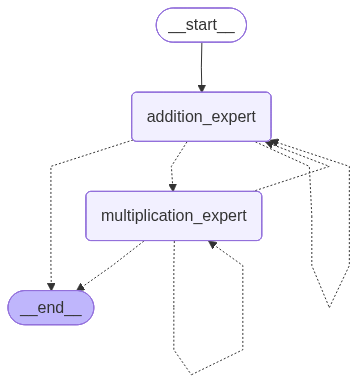

In [28]:
display(Image(app.get_graph().draw_mermaid_png()))

In [43]:
app.invoke({"messages": [{"role": "user", "content": "what's (3+5) * 12. Provide me the output"}]})

{'messages': [HumanMessage(content="what's (3+5) * 12. Provide me the output", additional_kwargs={}, response_metadata={}, id='ffcfa986-32cd-4f10-919e-63e74a678abe'),
  AIMessage(content='Processed by addition expert.', additional_kwargs={}, response_metadata={}, id='08c39c6e-5afb-4bf2-9b6b-165130b254f9', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='Processed by multiplication expert.', additional_kwargs={}, response_metadata={}, id='e59f6641-6253-492a-955f-26952d501c4e', tool_calls=[], invalid_tool_calls=[])]}

In [44]:
from langchain_core.messages import convert_to_messages
def pretty_print_messages(update):
    if isinstance(update, tuple):
        ns, update = update
        # Skip parent graph update in the printout

        if len(ns) ==0:
            return
        graph_id = ns[-1].split(":")[0]
        print(f"Update from subgraph {graph_id}:")
        print("\n")

    for node_name, node_update in update.items():
        print(f"Update from node {node_name}:")
        print("\n")

        for m in convert_to_messages(node_update["messages"]):
            m.pretty_print()
        print("\n")

In [46]:
# Let's run the graph with an expression that requires both addition and multiplication:
for chunk in app.stream(
    {"messages": [("user", "what's (3+5) * 12. Provide me the output")]},
):
    print("****chunk...*****")


    pretty_print_messages(chunk)


****chunk...*****
Update from node addition_expert:


================================== Ai Message ==================================

Processed by addition expert.


****chunk...*****
Update from node multiplication_expert:


================================== Ai Message ==================================

Processed by multiplication expert.




In [47]:
@tool
def transfer_to_travel_advisor():
    """Ask travel advisor for help."""
    return

@tool
def transfer_to_hotel_advisor():
    """Ask hotel advisor for help."""
    return

In [48]:
def travel_advisor(state: MessagesState) -> Command[Literal["hotel_advisor", "__end__"]]:
    system_prompt = (
        "You are a general travel expert that you can recommend travel destinations (e.g. countries, cities, etc)."
        "If you need hotel recommendations, ask 'hotel_advisor' for help."
    )

    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    ai_msg = groq_model.bind_tools([transfer_to_hotel_advisor]).invoke(messages)
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }



    return Command(
        update={"messages": [{"role": "assistant", "content": "Processed by multiplication expert."}]},
        goto="__end__" # Or route back to "addition_expert" if needed
    )